# CV PR 3 — Morphology, Bitwise Ops, Histograms, Face Detection & YOLO
## Classical Image Processing + Deep Learning Object Detection Pipeline


## Task 1: Environment Setup, Image I/O & Morphological Operations

### Step 1: Install Libraries

In [1]:
# !pip install -q opencv-python==5.0.0.* opencv-contrib-python==5.0.0.* ultralytics matplotlib numpy

### Step 2: Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import pandas as pd

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.11.0


In [3]:
# Make a folder to save our output plots
os.makedirs('plots', exist_ok=True)

### Step 3: Helper Function to Show Images

In [4]:
def show(img, title="Image", cmap=None):
    # Convert BGR (OpenCV) to RGB (matplotlib) for color images
    if len(img.shape) == 3:
        img_show = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_show = img
        cmap = 'gray'
    plt.imshow(img_show, cmap=cmap)
    plt.title(title)
    plt.axis('off')

### Step 4: Load a Grayscale Image and a Colour Image

In [5]:
gray_img = cv2.imread('CV_PR3_data/CV_PR3_data/images/baboon.jpg', cv2.IMREAD_GRAYSCALE)
color_img = cv2.imread('CV_PR3_data/CV_PR3_data/images/zidane.jpg', cv2.IMREAD_COLOR)

print("Gray image shape:", gray_img.shape, "| dtype:", gray_img.dtype)
print("Color image shape:", color_img.shape, "| dtype:", color_img.dtype)

Gray image shape: (512, 512) | dtype: uint8
Color image shape: (720, 1280, 3) | dtype: uint8


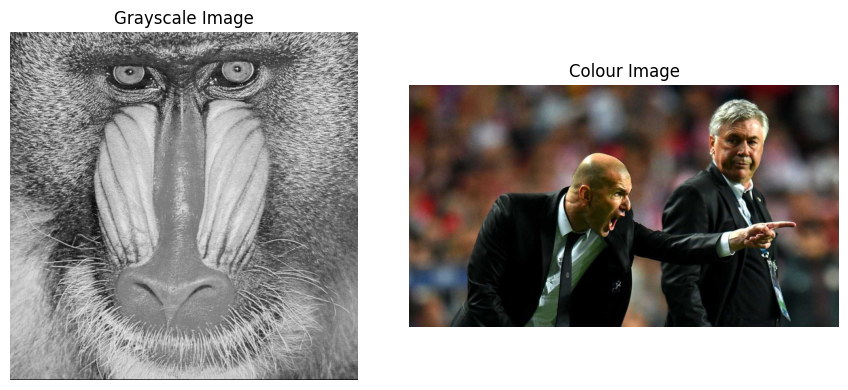

In [6]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); show(gray_img, "Grayscale Image")
plt.subplot(1,2,2); show(color_img, "Colour Image")
plt.tight_layout()
plt.show()

**Model Output:**
- Grayscale image has only 2 numbers in shape (height, width)
- Colour image has 3 numbers in shape (height, width, channels)
- Both images loaded correctly, dtype is uint8 (values 0-255)


### Step 5: Binarize an Image

In [7]:
morph_gray = cv2.cvtColor(cv2.imread('CV_PR3_data/CV_PR3_data/images/baboon.jpg'), cv2.COLOR_BGR2GRAY)
_, binary_img = cv2.threshold(morph_gray, 127, 255, cv2.THRESH_BINARY)

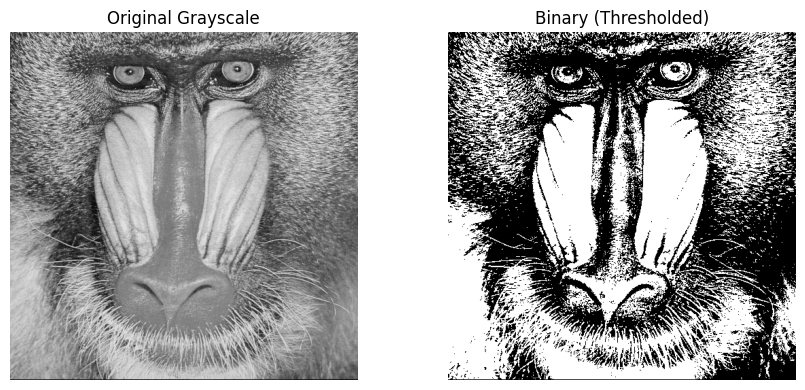

In [8]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); show(morph_gray, "Original Grayscale")
plt.subplot(1,2,2); show(binary_img, "Binary (Thresholded)")
plt.tight_layout()
plt.savefig('plots/binarize_comparison.png', dpi=120)
plt.show()

**Graph Interpretation:**
- White pixels = 255 (above threshold), black pixels = 0 (below threshold)
- Binary image keeps only the shape information, not the shading
- This binary image will be used for the morphology steps below


### Step 6: Apply the Four Morphological Operations

In [9]:
kernel = np.ones((5,5), np.uint8)

eroded = cv2.erode(binary_img, kernel)
dilated = cv2.dilate(binary_img, kernel)
opened = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel)

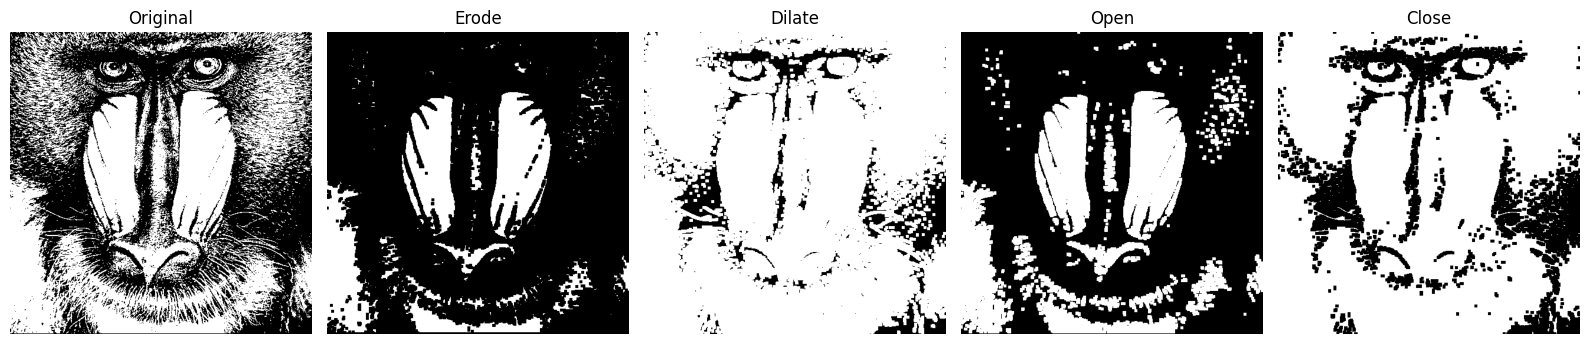

In [10]:
images = [binary_img, eroded, dilated, opened, closed]
titles = ["Original", "Erode", "Dilate", "Open", "Close"]

plt.figure(figsize=(16,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    show(images[i], titles[i])
plt.tight_layout()
plt.savefig('plots/morphology_grid.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Erode makes white regions smaller (shrinks them)
- Dilate makes white regions bigger (grows them)
- Open (erode then dilate) removes small white dots but keeps the big shape
- Close (dilate then erode) fills small black holes but keeps the big shape


### Step 7: Make a Noisy Binary Image

In [11]:
# Create a simple white square on a black background
noisy_shape = np.zeros((300,300), np.uint8)
cv2.rectangle(noisy_shape, (80,80), (220,220), 255, -1)

# Add random salt-and-pepper noise
np.random.seed(42)
noise_mask = np.random.rand(300,300)
noisy_shape[noise_mask < 0.02] = 255   # salt (white specks)
noisy_shape[noise_mask > 0.98] = 0     # pepper (black specks)

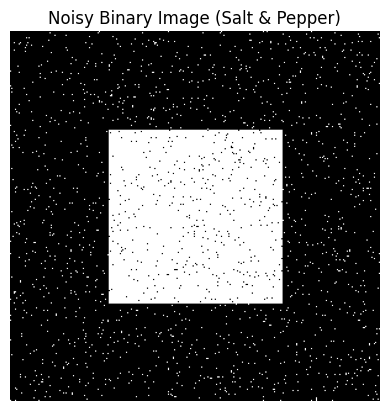

In [12]:
show(noisy_shape, "Noisy Binary Image (Salt & Pepper)")
plt.savefig('plots/noisy_shape.png', dpi=120)
plt.show()

### Step 8: Compare Kernel Shapes and Sizes

In [13]:
shapes = {'RECT': cv2.MORPH_RECT, 'ELLIPSE': cv2.MORPH_ELLIPSE, 'CROSS': cv2.MORPH_CROSS}
sizes = [3, 5, 9]

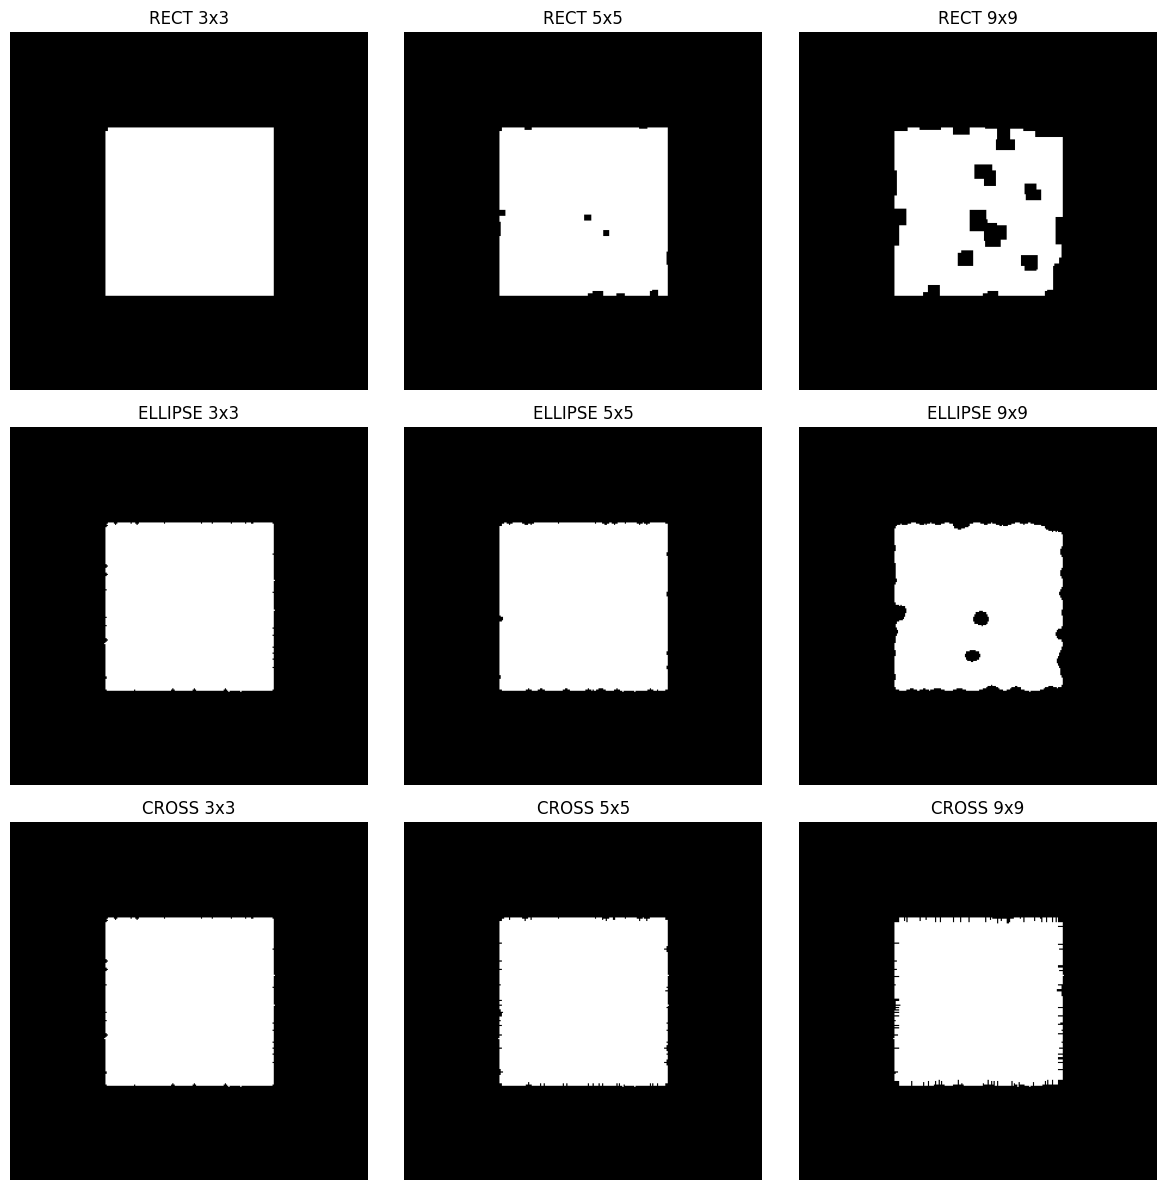

In [14]:
plt.figure(figsize=(12,12))
plot_num = 1
for shape_name, shape_code in shapes.items():
    for size in sizes:
        k = cv2.getStructuringElement(shape_code, (size,size))
        # Open removes salt noise (white specks), then Close fills pepper noise (black holes)
        step1 = cv2.morphologyEx(noisy_shape, cv2.MORPH_OPEN, k)
        result = cv2.morphologyEx(step1, cv2.MORPH_CLOSE, k)
        plt.subplot(3,3,plot_num)
        show(result, f"{shape_name} {size}x{size}")
        plot_num += 1
plt.tight_layout()
plt.savefig('plots/kernel_comparison_grid.png', dpi=120)
plt.show()

**Graph Interpretation:**
- RECT 3x3 gives the cleanest result -- a perfect square with no noise left at all
- Bigger kernels (5x5, 9x9) do not always work better -- RECT actually leaves black holes behind at larger sizes
- CROSS kernels leave a rough, jagged edge on the square at every size, since a cross shape is not smooth in every direction
- ELLIPSE kernels give a smoother, more rounded edge than CROSS, but still not as clean as RECT 3x3 here
- Smallest kernel that still removes the noise is usually the safest choice -- bigger is not always better


### Step 9: Why Morphology Works

- **Erosion** is a local **minimum** filter — it looks at each pixel's neighbourhood and keeps the smallest (darkest) value. This shrinks white regions and removes small bright noise.
- **Dilation** is a local **maximum** filter — it keeps the largest (brightest) value in the neighbourhood. This grows white regions and fills small dark gaps.
- **Opening** = erosion then dilation. It removes small noise specks while keeping the overall shape and size close to the original.
- **Closing** = dilation then erosion. It fills small holes inside the object without shrinking the object.

**Real scenario:** before sending a camera mask to a face/object detector, use **opening** to clean small noise specks from the background, and use **closing** to fill small gaps inside a detected region (like a hole in a person's silhouette).


## Task 2: Bitwise Operations & Image Histograms

### Step 10: Make Two Masks

In [15]:
canvas1 = np.zeros((300,300), np.uint8)
cv2.circle(canvas1, (150,150), 100, 255, -1)

canvas2 = np.zeros((300,300), np.uint8)
cv2.rectangle(canvas2, (60,60), (240,240), 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

### Step 11: Apply AND / OR / XOR / NOT

In [16]:
and_result = cv2.bitwise_and(canvas1, canvas2)
or_result = cv2.bitwise_or(canvas1, canvas2)
xor_result = cv2.bitwise_xor(canvas1, canvas2)
not_result = cv2.bitwise_not(canvas1)

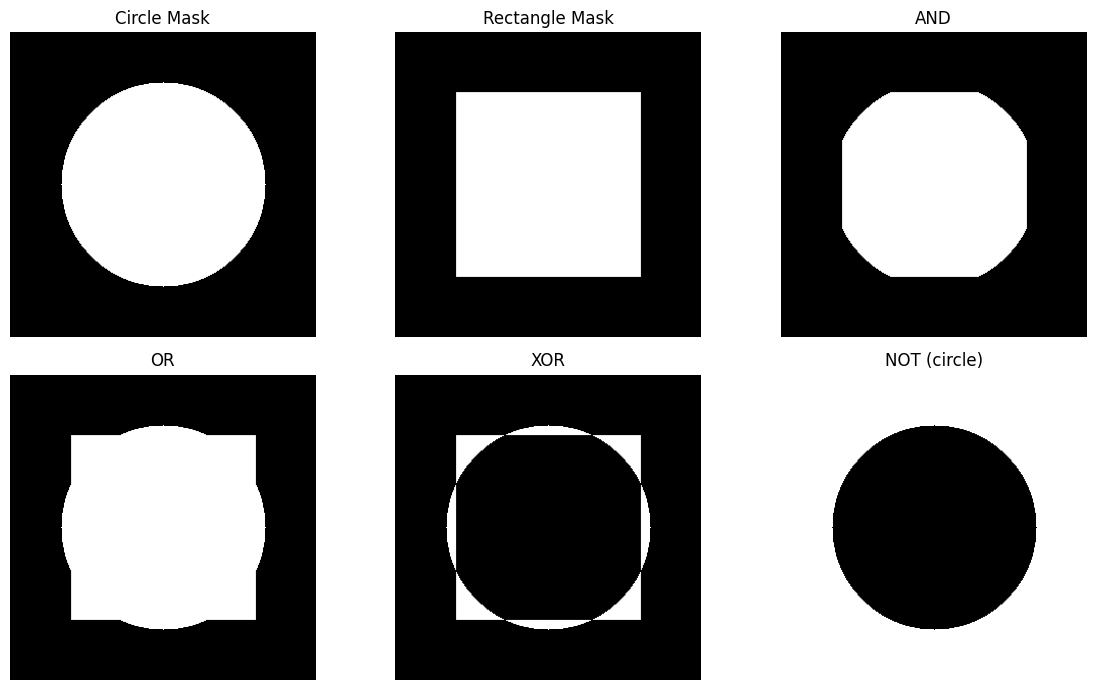

In [17]:
imgs = [canvas1, canvas2, and_result, or_result, xor_result, not_result]
titles = ["Circle Mask", "Rectangle Mask", "AND", "OR", "XOR", "NOT (circle)"]

plt.figure(figsize=(12,7))
for i in range(6):
    plt.subplot(2,3,i+1)
    show(imgs[i], titles[i])
plt.tight_layout()
plt.savefig('plots/bitwise_grid.png', dpi=120)
plt.show()

**Graph Interpretation:**
- AND keeps only the area where both shapes overlap
- OR keeps the area covered by either shape
- XOR keeps the area covered by only one shape, not both
- NOT flips white to black and black to white


### Step 12: Masked Overlay on a Real Photo

In [18]:
photo = cv2.imread('CV_PR3_data/CV_PR3_data/images/fruits.jpg')
photo = cv2.resize(photo, (300,300))

circle_mask = np.zeros((300,300), np.uint8)
cv2.circle(circle_mask, (150,150), 80, 255, -1)

masked_photo = cv2.bitwise_and(photo, photo, mask=circle_mask)

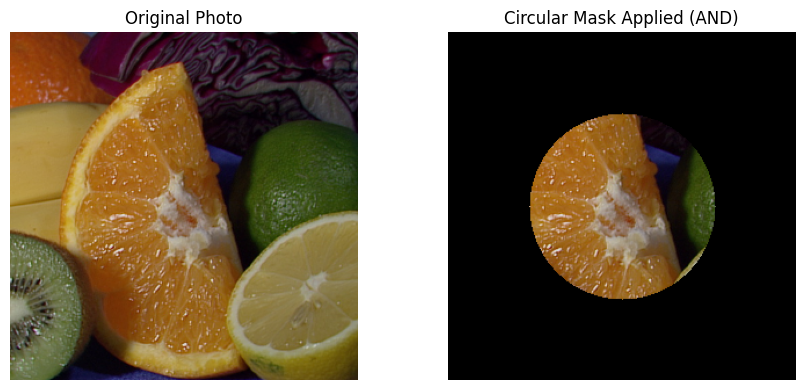

In [19]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); show(photo, "Original Photo")
plt.subplot(1,2,2); show(masked_photo, "Circular Mask Applied (AND)")
plt.tight_layout()
plt.savefig('plots/masked_overlay.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Only the circle area of the photo is kept
- Everything outside the circle mask becomes black
- This is how we can cut out a Region of Interest (ROI) from a photo


### Step 13: Composite a Watermark onto a Background

In [20]:
background = cv2.imread('CV_PR3_data/CV_PR3_data/images/messi5.jpg')
background = cv2.resize(background, (400,300))   # width=400, height=300

# Make a simple watermark shape (a white box with text), same size as background
watermark = np.zeros((300,400), np.uint8)   # height=300, width=400 -- matches background
cv2.rectangle(watermark, (10,260), (150,290), 255, -1)
cv2.putText(watermark, 'DEMO', (15,283), cv2.FONT_HERSHEY_SIMPLEX, 0.9, 255, 2)

watermark_color = cv2.cvtColor(watermark, cv2.COLOR_GRAY2BGR)
composited = cv2.bitwise_or(background, watermark_color)

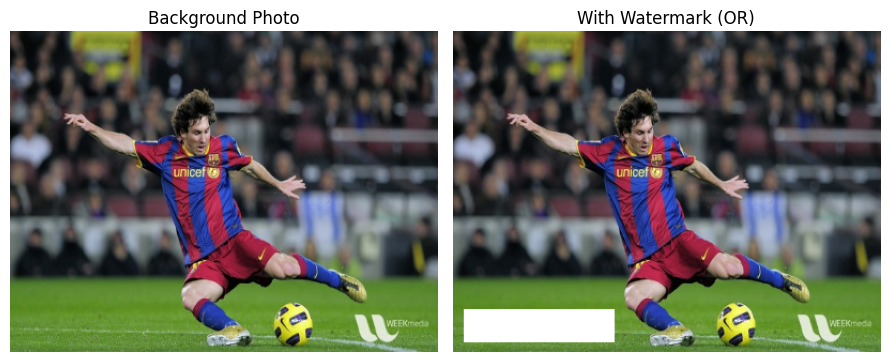

In [21]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); show(background, "Background Photo")
plt.subplot(1,2,2); show(composited, "With Watermark (OR)")
plt.tight_layout()
plt.savefig('plots/watermark_overlay.png', dpi=120)
plt.show()

**Graph Interpretation:**
- The white "DEMO" watermark box is now visible on top of the photo
- OR combines the bright watermark pixels with the photo pixels
- This is a simple way to stamp a logo or label onto an image


### Step 14: Grayscale Histogram

In [22]:
gray_photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
gray_hist = cv2.calcHist([gray_photo], [0], None, [256], [0,256])

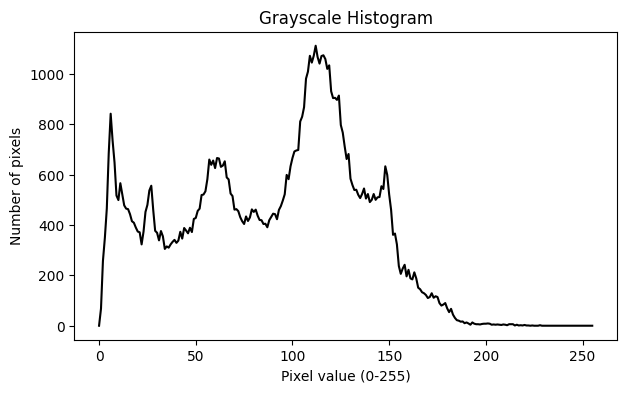

In [23]:
plt.figure(figsize=(7,4))
plt.plot(gray_hist, color='black')
plt.title("Grayscale Histogram")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Number of pixels")
plt.savefig('plots/grayscale_histogram.png', dpi=120)
plt.show()

**Graph Interpretation:**
- The x-axis shows brightness (0 = black, 255 = white)
- The y-axis shows how many pixels have that brightness
- Tall bars show which brightness levels are most common in the photo


### Step 15: Colour Histogram (B, G, R channels)

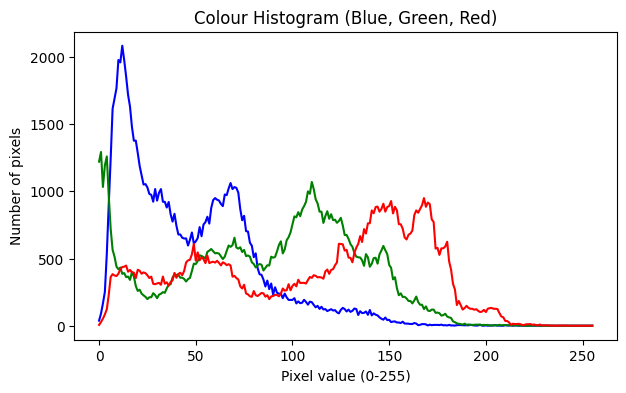

In [24]:
colors = ('b', 'g', 'r')
plt.figure(figsize=(7,4))
for i, col in enumerate(colors):
    hist = cv2.calcHist([photo], [i], None, [256], [0,256])
    plt.plot(hist, color=col)
plt.title("Colour Histogram (Blue, Green, Red)")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Number of pixels")
plt.savefig('plots/color_histogram.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Each line shows how much of that colour channel is in the photo
- Where the red line is high, the photo has a lot of red pixels
- Comparing the 3 lines tells us the overall colour balance of the photo


### Step 16: Brightness & Contrast Adjustment

In [25]:
bright_img = cv2.convertScaleAbs(photo, alpha=1.5, beta=30)
dark_img = cv2.convertScaleAbs(photo, alpha=0.7, beta=-30)

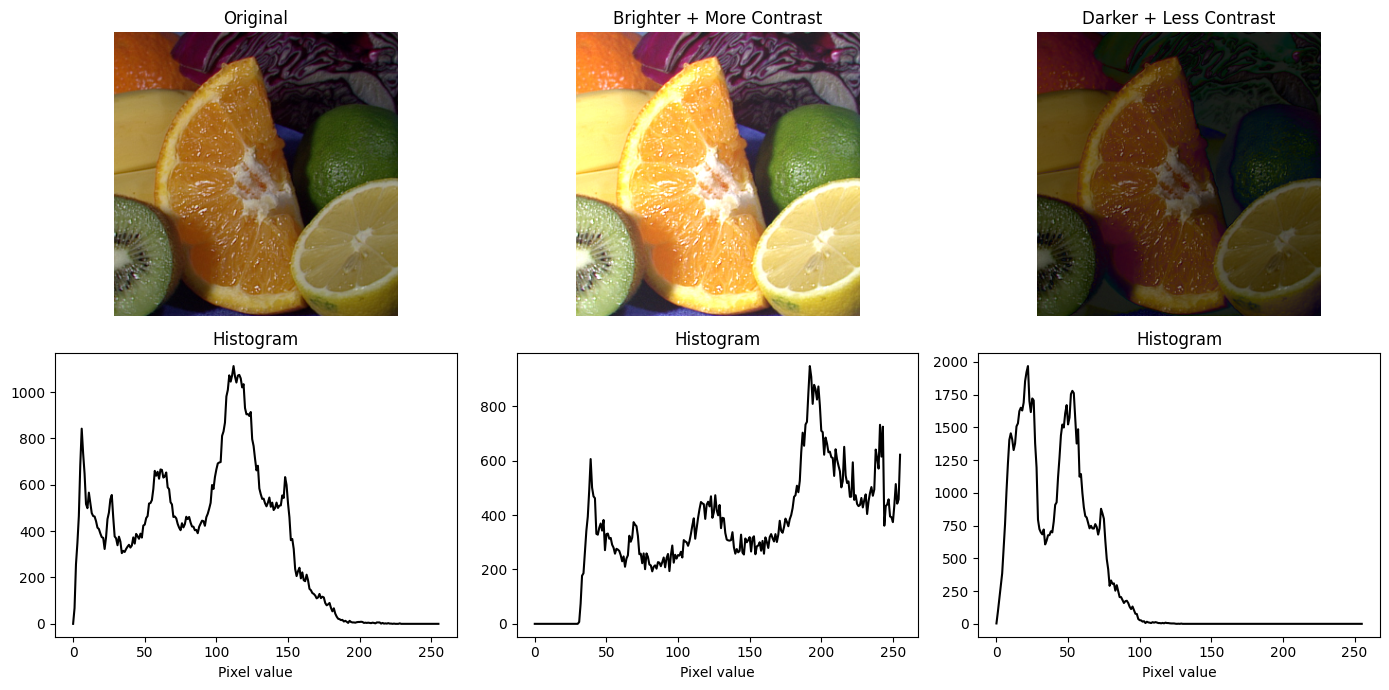

In [26]:
versions = [photo, bright_img, dark_img]
version_titles = ["Original", "Brighter + More Contrast", "Darker + Less Contrast"]

plt.figure(figsize=(14,7))
for i in range(3):
    plt.subplot(2,3,i+1)
    show(versions[i], version_titles[i])

    plt.subplot(2,3,i+4)
    gray_v = cv2.cvtColor(versions[i], cv2.COLOR_BGR2GRAY)
    hist_v = cv2.calcHist([gray_v], [0], None, [256], [0,256])
    plt.plot(hist_v, color='black')
    plt.title("Histogram")
    plt.xlabel("Pixel value")

plt.tight_layout()
plt.savefig('plots/brightness_contrast_comparison.png', dpi=120)
plt.show()

**Graph Interpretation:**
- The brighter image's histogram shifts to the right (more high values)
- The darker image's histogram shifts to the left (more low values)
- The brighter version's histogram is also more spread out (more contrast)


### Step 17: Why Alpha/Beta and Histograms Matter

The formula is: **new_pixel = alpha × pixel + beta**

- **alpha** (contrast gain) stretches or compresses the histogram spread around its mean
- **beta** (brightness offset) shifts the whole histogram left (darker) or right (brighter)
- A **narrow** histogram means low contrast (the image looks washed out / flat)
- A histogram **clipped at 0 or 255** means the image is under-exposed or over-exposed

**Why this matters later:** before sending a photo to the face or object detector in Task 3/4, we can look at its histogram to check if it is too dark, too bright, or too flat — and fix it with alpha/beta before detection.


## Task 3: Face Detection with YuNet

### Step 18: Load the YuNet Face Detector

In [27]:
YUNET_PATH = 'CV_PR3_data/CV_PR3_data/models/face_detection_yunet_2023mar.onnx'

def build_face_detector(width, height, score_thresh=0.9):
    detector = cv2.FaceDetectorYN_create(YUNET_PATH, "", (width, height), score_threshold=score_thresh)
    return detector

In [28]:
test_detector = build_face_detector(320, 320)
print("YuNet detector loaded successfully.")

YuNet detector loaded successfully.


**Model Interpretation:**
- YuNet is a small deep learning model made just for finding faces
- It needs the image width and height set before it can detect
- It gives back a box (x, y, width, height), a confidence score, and 5 face landmark points per face


### Step 19: Detect Faces in Several Static Images

In [29]:
face_test_images = ['zidane.jpg', 'messi5.jpg', 'basketball1.png', 'bus.jpg']

In [30]:
def detect_faces(img_path, score_thresh=0.9):
    img = cv2.imread('CV_PR3_data/CV_PR3_data/images/' + img_path)
    h, w = img.shape[:2]
    detector = build_face_detector(w, h, score_thresh)
    _, faces = detector.detect(img)
    return img, faces

In [31]:
def draw_faces(img, faces):
    output = img.copy()
    if faces is not None:
        for face in faces:
            x, y, w, h = face[0:4].astype(int)
            score = face[-1]
            cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)
            cv2.putText(output, f"{score:.2f}", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
            # Draw the 5 landmark points (eyes, nose, mouth corners)
            landmarks = face[4:14].reshape(5,2).astype(int)
            for (lx, ly) in landmarks:
                cv2.circle(output, (lx,ly), 2, (0,0,255), -1)
    return output

In [32]:
face_results = []
for img_name in face_test_images:
    img, faces = detect_faces(img_name)
    output = draw_faces(img, faces)
    n_faces = 0 if faces is None else len(faces)
    face_results.append((output, img_name, n_faces))
    print(img_name, "-> faces found:", n_faces) 

zidane.jpg -> faces found: 2
messi5.jpg -> faces found: 1
basketball1.png -> faces found: 0
bus.jpg -> faces found: 2


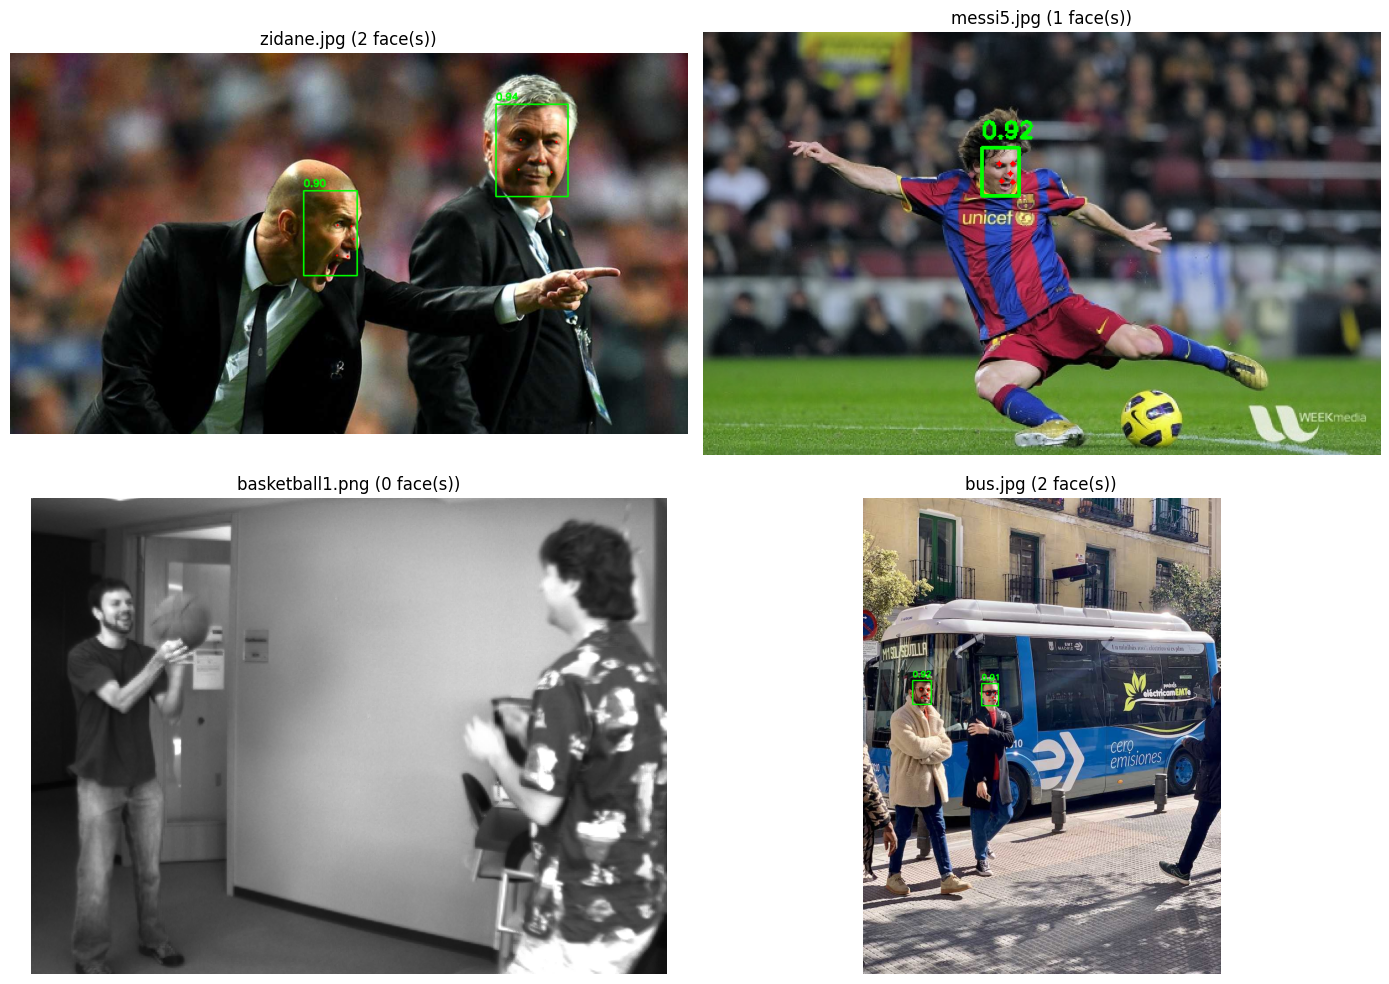

In [33]:
plt.figure(figsize=(14,10))
for i, (output, name, n_faces) in enumerate(face_results):
    plt.subplot(2,2,i+1)
    show(output, f"{name} ({n_faces} face(s))")
plt.tight_layout()
plt.savefig('plots/face_detection_comparison.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Green boxes show detected faces, red dots show eyes/nose/mouth landmarks
- zidane.jpg and messi5.jpg show clear front-facing faces, both found easily
- basketball1.png found 0 faces -- both people are turned away/sideways from the camera, and YuNet needs at least a partial front view of a face to detect it
- bus.jpg still found both people wearing sunglasses -- YuNet can handle sunglasses, but not a fully turned-away head


### Step 20: Real-Time Detection Speed (FPS)

In [34]:
def get_frame_source(static_img_path, n_frames):
    # Try a real webcam first
    cap = cv2.VideoCapture(0)
    if cap.isOpened():
        print("Using a real webcam.")
        frames = []
        for i in range(n_frames):
            ok, frame = cap.read()
            if ok:
                frames.append(frame)
        cap.release()
        return frames
    else:
        # No webcam here, so we simulate a live camera feed using one photo
        # (small random noise added to each frame, like a real camera would have)
        print("No webcam found -- simulating a live feed from a photo instead.")
        base_img = cv2.imread('data/images/' + static_img_path)
        frames = []
        for i in range(n_frames):
            noise = np.random.randint(-5, 5, base_img.shape, dtype=np.int16)
            frame = np.clip(base_img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
            frames.append(frame)
        return frames

In [35]:
sim_frames = get_frame_source('zidane.jpg', n_frames=30)
h, w = sim_frames[0].shape[:2]
face_detector = build_face_detector(w, h)

Using a real webcam.


In [36]:
start_time = time.time()
for frame in sim_frames:
    _, faces = face_detector.detect(frame)
end_time = time.time()

face_fps = len(sim_frames) / (end_time - start_time)
print(f"YuNet face detection speed: {face_fps:.2f} FPS")

YuNet face detection speed: 60.80 FPS


**Model Interpretation:**
- We measured how many frames per second (FPS) the face detector can process
- Higher FPS means the detector can keep up with a live video feed
- This speed was measured on CPU only (no GPU) in this notebook environment


### Step 21: Score Threshold Experiment

In [37]:
thresholds = [0.5, 0.7, 0.9]
threshold_counts = []

for t in thresholds:
    img, faces = detect_faces('bus.jpg', score_thresh=t)
    n_faces = 0 if faces is None else len(faces)
    threshold_counts.append(n_faces)
    print(f"score_threshold={t} -> faces found: {n_faces}")

score_threshold=0.5 -> faces found: 2
score_threshold=0.7 -> faces found: 2
score_threshold=0.9 -> faces found: 2


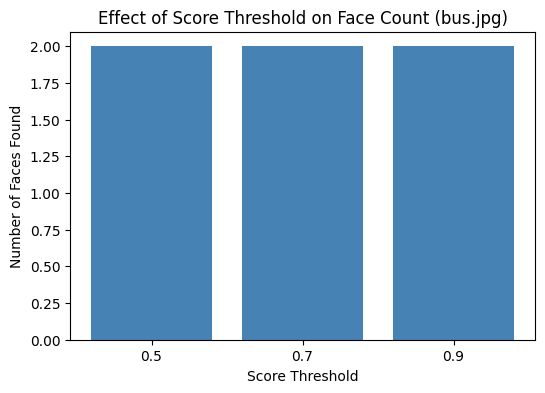

In [38]:
plt.figure(figsize=(6,4))
plt.bar([str(t) for t in thresholds], threshold_counts, color='steelblue')
plt.xlabel("Score Threshold")
plt.ylabel("Number of Faces Found")
plt.title("Effect of Score Threshold on Face Count (bus.jpg)")
plt.savefig('plots/threshold_experiment.png', dpi=120)
plt.show()

**Graph Interpretation:**
- The bar chart stays exactly the same height (2 faces) at all three thresholds
- This means both sunglasses-covered faces were detected with high confidence (above 0.9), not borderline
- A threshold only starts to matter once it goes above a face's actual confidence score -- here that point was never reached in the 0.5-0.9 range


### Step 22: Face Anonymization (Blur)

In [39]:
img, faces = detect_faces('zidane.jpg', score_thresh=0.9)
blurred_img = img.copy()

if faces is not None:
    for face in faces:
        x, y, w, h = face[0:4].astype(int)
        x, y = max(x,0), max(y,0)
        face_region = blurred_img[y:y+h, x:x+w]
        if face_region.size > 0:
            blurred_face = cv2.GaussianBlur(face_region, (35,35), 30)
            blurred_img[y:y+h, x:x+w] = blurred_face

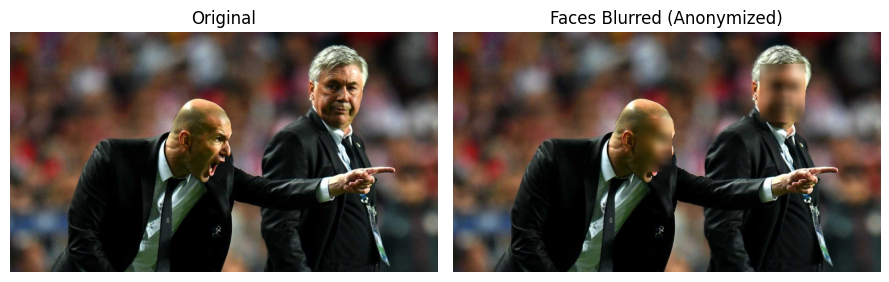

In [40]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1); show(img, "Original")
plt.subplot(1,2,2); show(blurred_img, "Faces Blurred (Anonymized)")
plt.tight_layout()
plt.savefig('plots/face_anonymization.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Each detected face box is now blurred so the person cannot be identified
- The rest of the photo stays sharp and unchanged
- This is a simple, useful privacy tool for photos or video shared in public


### Step 23: Why YuNet

- YuNet is a small **CNN (Convolutional Neural Network)** trained only to find faces, so it is fast and light
- It also predicts 5 **landmark points** (eyes, nose, mouth corners) with every face, not just a box
- The **score threshold** controls a trade-off: low threshold = catches more faces but more false alarms; high threshold = fewer false alarms but may miss hard faces (side-profile, sunglasses, low light)

**Real scenario:** a security camera at night should probably use a **lower** score threshold to avoid missing anyone, while a photo-tagging app can use a **higher** threshold to avoid tagging the wrong "face" on a random object.


## Task 4: Object Detection with YOLO

### Step 24: Load the YOLO Model

In [41]:
from ultralytics import YOLO

yolo_model = YOLO('data/models/yolov8n.pt')
print("YOLOv8n loaded. Number of classes:", len(yolo_model.names))

YOLOv8n loaded. Number of classes: 80


**Model Interpretation:**
- YOLOv8n ("nano") is the smallest, fastest version of YOLOv8
- It can detect 80 different everyday object classes (person, car, bus, dog, chair, etc.)
- "n" (nano) trades a little accuracy for a lot of extra speed, which is good for real-time use


### Step 25: Detect Objects in Static Images

In [42]:
yolo_test_images = ['bus.jpg', 'zidane.jpg', 'messi5.jpg']

In [43]:
yolo_results = []
for img_name in yolo_test_images:
    result = yolo_model('CV_PR3_data/CV_PR3_data/images/' + img_name, verbose=False)[0]
    plotted = result.plot()   # draws boxes + labels for us
    yolo_results.append((plotted, img_name, len(result.boxes)))
    print(img_name, "-> objects found:", len(result.boxes))

bus.jpg -> objects found: 6
zidane.jpg -> objects found: 3
messi5.jpg -> objects found: 9


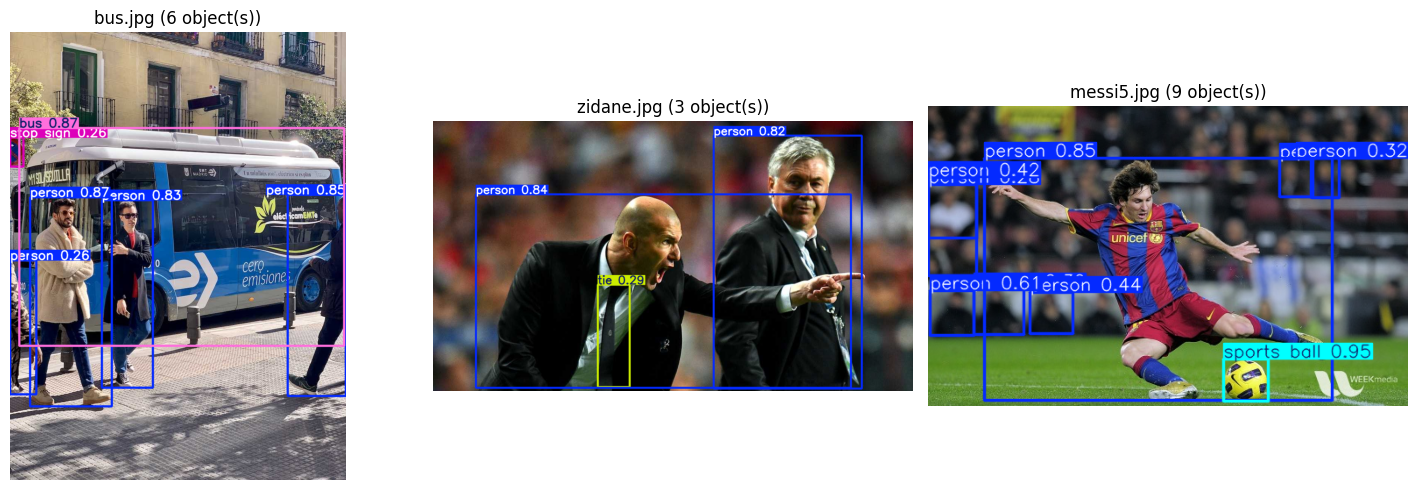

In [44]:
plt.figure(figsize=(15,5))
for i, (plotted, name, n_obj) in enumerate(yolo_results):
    plt.subplot(1,3,i+1)
    show(plotted, f"{name} ({n_obj} object(s))")
plt.tight_layout()
plt.savefig('plots/yolo_detections.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Each box shows the object class name and confidence score
- bus.jpg finds a bus and several people
- zidane.jpg and messi5.jpg mostly find "person" and (for messi5) a "sports ball"


### Step 26: Real-Time Detection Speed (FPS)

In [45]:
sim_frames_yolo = get_frame_source('CV_PR3_data/CV_PR3_data/images/bus.jpg', n_frames=20)

Using a real webcam.


In [46]:
start_time = time.time()
for frame in sim_frames_yolo:
    results = yolo_model(frame, verbose=False)
end_time = time.time()

yolo_fps = len(sim_frames_yolo) / (end_time - start_time)
print(f"YOLO detection speed: {yolo_fps:.2f} FPS")

YOLO detection speed: 23.36 FPS


**Model Interpretation:**
- This is how many frames per second YOLO can process on this CPU
- YOLO usually runs slower than YuNet because it looks for 80 different object types, not just one


### Step 27: Confidence Threshold Tuning

In [47]:
conf_values = [0.25, 0.5, 0.75]
conf_counts = []

for c in conf_values:
    result = yolo_model('CV_PR3_data/CV_PR3_data/images/bus.jpg', conf=c, verbose=False)[0]
    conf_counts.append(len(result.boxes))
    print(f"confidence={c} -> objects found: {len(result.boxes)}")

confidence=0.25 -> objects found: 6
confidence=0.5 -> objects found: 4
confidence=0.75 -> objects found: 4


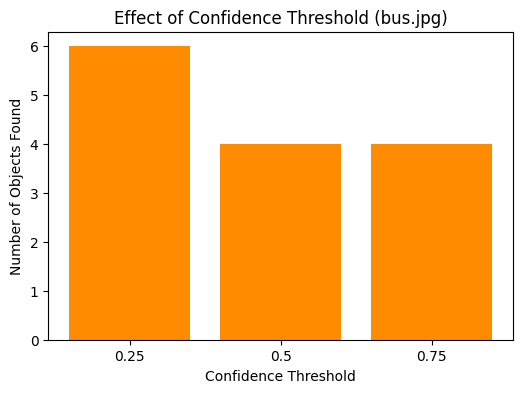

In [48]:
plt.figure(figsize=(6,4))
plt.bar([str(c) for c in conf_values], conf_counts, color='darkorange')
plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Objects Found")
plt.title("Effect of Confidence Threshold (bus.jpg)")
plt.savefig('plots/confidence_experiment.png', dpi=120)
plt.show()

**Graph Interpretation:**
- A low confidence threshold (0.25) keeps more boxes, even unsure ones
- A high confidence threshold (0.75) keeps only very sure detections
- Fewer boxes remain as the threshold goes up


### Step 28: IoU Threshold Tuning (Duplicate Boxes)

In [49]:
iou_values = [0.3, 0.5, 0.7]
iou_counts = []

for i in iou_values:
    result = yolo_model('CV_PR3_data/CV_PR3_data/images/bus.jpg', iou=i, conf=0.25, verbose=False)[0]
    iou_counts.append(len(result.boxes))
    print(f"iou={i} -> objects found: {len(result.boxes)}")

iou=0.3 -> objects found: 6
iou=0.5 -> objects found: 6
iou=0.7 -> objects found: 6


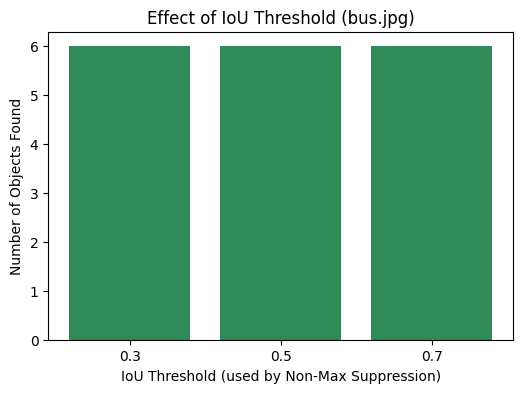

In [50]:
plt.figure(figsize=(6,4))
plt.bar([str(i) for i in iou_values], iou_counts, color='seagreen')
plt.xlabel("IoU Threshold (used by Non-Max Suppression)")
plt.ylabel("Number of Objects Found")
plt.title("Effect of IoU Threshold (bus.jpg)")
plt.savefig('plots/iou_experiment.png', dpi=120)
plt.show()

In [51]:
# A very high IoU threshold lets Non-Max Suppression keep almost every overlapping box.
# This gives us a clear "before cleanup" vs "after cleanup" example.
clean_result = yolo_model('CV_PR3_data/CV_PR3_data/images/bus.jpg', iou=0.5, conf=0.25, verbose=False)[0]
duplicate_result = yolo_model('CV_PR3_data/CV_PR3_data/images/bus.jpg', iou=0.99, conf=0.25, verbose=False)[0]

clean_plot = clean_result.plot()
duplicate_plot = duplicate_result.plot()

print("Normal IoU (0.5):", len(clean_result.boxes), "boxes")
print("Very high IoU (0.99):", len(duplicate_result.boxes), "boxes")

Normal IoU (0.5): 6 boxes
Very high IoU (0.99): 34 boxes


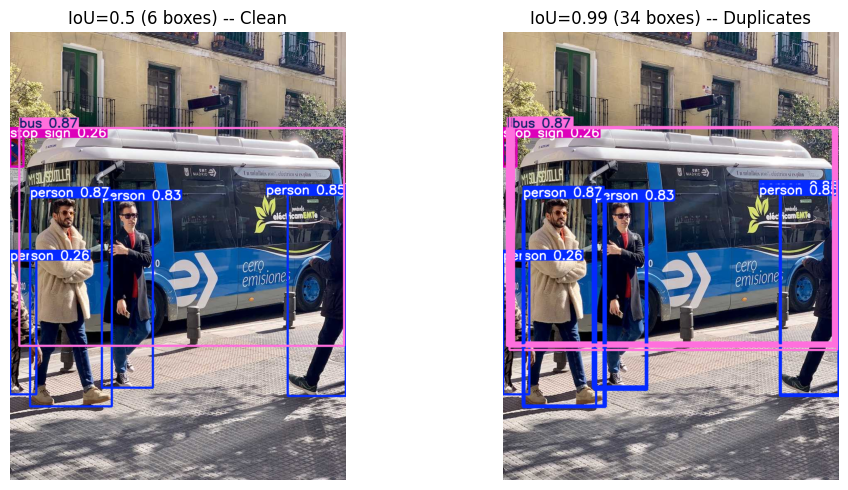

In [52]:
plt.figure(figsize=(11,5))
plt.subplot(1,2,1); show(clean_plot, f"IoU=0.5 ({len(clean_result.boxes)} boxes) -- Clean")
plt.subplot(1,2,2); show(duplicate_plot, f"IoU=0.99 ({len(duplicate_result.boxes)} boxes) -- Duplicates")
plt.tight_layout()
plt.savefig('plots/nms_duplicate_demo.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Non-Max Suppression (NMS) removes duplicate boxes that overlap the same object
- At IoU=0.5 (normal setting), each object has just one clean box
- At IoU=0.99, NMS almost stops working, so many overlapping duplicate boxes survive on the same object
- This shows the IoU threshold controls how strict NMS is about calling two boxes "duplicates"


### Step 29: Detections Per Class

In [53]:
class_counts = {}
for img_name in yolo_test_images:
    result = yolo_model('CV_PR3_data/CV_PR3_data/images/' + img_name, verbose=False)[0]
    for cls_id in result.boxes.cls:
        cls_name = yolo_model.names[int(cls_id)]
        class_counts[cls_name] = class_counts.get(cls_name, 0) + 1

print(class_counts)

{'bus': 1, 'person': 14, 'stop sign': 1, 'tie': 1, 'sports ball': 1}


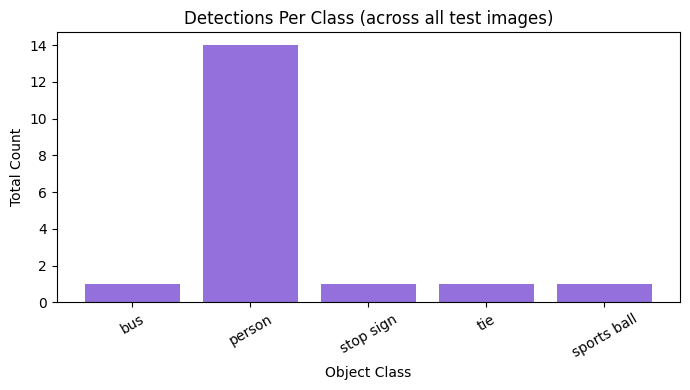

In [54]:
plt.figure(figsize=(7,4))
plt.bar(class_counts.keys(), class_counts.values(), color='mediumpurple')
plt.xlabel("Object Class")
plt.ylabel("Total Count")
plt.title("Detections Per Class (across all test images)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/class_counts.png', dpi=120)
plt.show()

**Graph Interpretation:**
- "person" is the most common class across our test photos
- Other classes (bus, sports ball, etc.) appear only in specific photos
- This tally tells us what kind of objects our small test set mostly contains


### Step 30: Why YOLO Generalizes

- YOLO looks at the **whole image once** and divides it into a grid, predicting boxes and classes for every grid cell at the same time (this is why it's called "You Only Look Once")
- It was trained on the **COCO dataset**, which has 80 common object classes and thousands of example photos for each one -- this is why one single model can find people, buses, sports balls, and more
- **Non-Max Suppression (NMS)** cleans up duplicate boxes, using the IoU threshold to decide how much overlap counts as "the same object"

**Real scenario:** a "nano" model like YOLOv8n is a good choice for a phone app or small robot with limited compute, while a bigger YOLOv8 variant (small/medium/large) would be used on a server with a strong GPU, trading speed for extra accuracy.


## Task 5: Integrated Pipeline & Final Comparison

### Step 31: Combine YuNet + YOLO in One Function

In [55]:
def run_combined_pipeline(frame):
    output = frame.copy()
    h, w = frame.shape[:2]

    # Faces in green
    fd = build_face_detector(w, h)
    _, faces = fd.detect(frame)
    if faces is not None:
        for face in faces:
            x, y, fw, fh = face[0:4].astype(int)
            cv2.rectangle(output, (x,y), (x+fw,y+fh), (0,255,0), 2)
            cv2.putText(output, "face", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    # Objects in red
    result = yolo_model(frame, verbose=False)[0]
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cls_name = yolo_model.names[int(box.cls[0])]
        cv2.rectangle(output, (x1,y1), (x2,y2), (0,0,255), 2)
        cv2.putText(output, cls_name, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    return output

In [56]:
test_frame = cv2.imread('CV_PR3_data/CV_PR3_data/images/bus.jpg')
combined_output = run_combined_pipeline(test_frame)

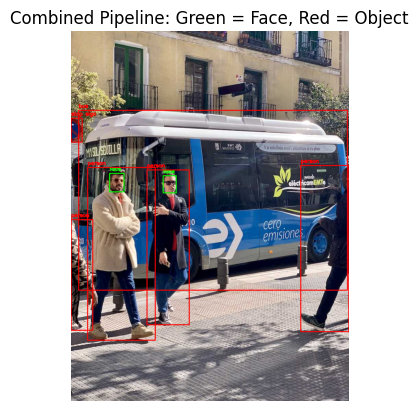

In [57]:
show(combined_output, "Combined Pipeline: Green = Face, Red = Object")
plt.savefig('plots/combined_pipeline.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Green boxes are faces found by YuNet
- Red boxes are objects (person, bus, etc.) found by YOLO
- Both models run on the exact same frame, one after the other


### Step 32: Does Cleaning the Frame First Help?

In [58]:
# Add noise to simulate a bad camera frame
np.random.seed(42)
noisy_frame = test_frame.copy()
noise = np.random.randint(-40, 40, noisy_frame.shape, dtype=np.int16)
noisy_frame = np.clip(noisy_frame.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Clean it up using morphological opening on each colour channel
kernel_clean = np.ones((3,3), np.uint8)
cleaned_frame = cv2.morphologyEx(noisy_frame, cv2.MORPH_OPEN, kernel_clean)

In [59]:
result_noisy = yolo_model(noisy_frame, verbose=False)[0]
result_cleaned = yolo_model(cleaned_frame, verbose=False)[0]

print("Objects found in noisy frame:", len(result_noisy.boxes))
print("Objects found in cleaned frame:", len(result_cleaned.boxes))

Objects found in noisy frame: 6
Objects found in cleaned frame: 4


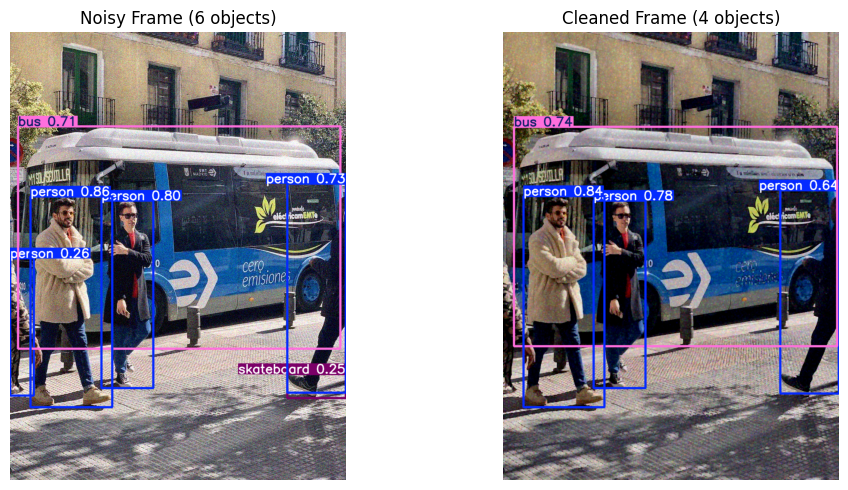

In [60]:
plt.figure(figsize=(11,5))
plt.subplot(1,2,1); show(result_noisy.plot(), f"Noisy Frame ({len(result_noisy.boxes)} objects)")
plt.subplot(1,2,2); show(result_cleaned.plot(), f"Cleaned Frame ({len(result_cleaned.boxes)} objects)")
plt.tight_layout()
plt.savefig('plots/precleaning_comparison.png', dpi=120)
plt.show()

**Graph Interpretation:**
- The noisy frame simulates a poor-quality camera picture
- Morphological opening smooths out speckled noise, but it also blurs fine edges and texture
- Here, cleaning the frame actually *reduced* the object count (6 -> 4) instead of improving it
- This shows morphological cleaning is not automatically helpful for deep learning models -- smoothing can remove the fine detail YOLO relies on, so it should be tested, not assumed


### Step 33: FPS Benchmark — Face Only vs YOLO Only vs Combined

In [61]:
bench_frames = get_frame_source('CV_PR3_data/CV_PR3_data/images/bus.jpg', n_frames=15)
h, w = bench_frames[0].shape[:2]
bench_detector = build_face_detector(w, h)

Using a real webcam.


In [62]:
# Face detection only
t0 = time.time()
for frame in bench_frames:
    bench_detector.detect(frame)
face_only_fps = len(bench_frames) / (time.time() - t0)

# YOLO only
t0 = time.time()
for frame in bench_frames:
    yolo_model(frame, verbose=False)
yolo_only_fps = len(bench_frames) / (time.time() - t0)

# Combined pipeline
t0 = time.time()
for frame in bench_frames:
    run_combined_pipeline(frame)
combined_fps = len(bench_frames) / (time.time() - t0)

print(f"Face only:  {face_only_fps:.2f} FPS")
print(f"YOLO only:  {yolo_only_fps:.2f} FPS")
print(f"Combined:   {combined_fps:.2f} FPS")

Face only:  22.43 FPS
YOLO only:  18.93 FPS
Combined:   10.05 FPS


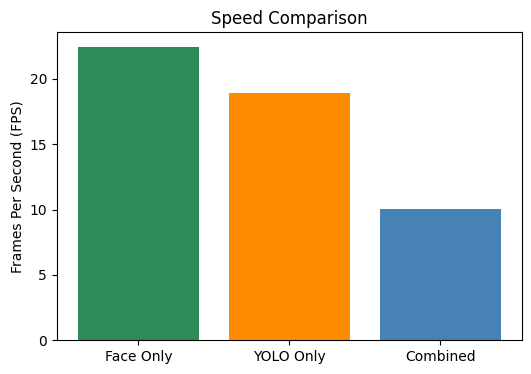

In [63]:
plt.figure(figsize=(6,4))
plt.bar(["Face Only", "YOLO Only", "Combined"], [face_only_fps, yolo_only_fps, combined_fps],
        color=['seagreen','darkorange','steelblue'])
plt.ylabel("Frames Per Second (FPS)")
plt.title("Speed Comparison")
plt.savefig('plots/fps_comparison.png', dpi=120)
plt.show()

**Graph Interpretation:**
- Face-only detection is usually the fastest, since it only looks for one thing
- YOLO-only is slower, since it checks for 80 different object classes
- Combined (both models on every frame) is the slowest, since it does both jobs one after another


### Step 34: Final Comparison Table

In [64]:
summary_table = pd.DataFrame([
    {"Technique": "Morphology (erode/dilate/open/close)", "Type": "Classical", "Detects": "Shapes/noise in binary images", "Lighting Robustness": "N/A (binary input)", "Speed": "Very Fast", "Best Use Case": "Cleaning masks before detection"},
    {"Technique": "Bitwise Ops + Histograms",             "Type": "Classical", "Detects": "Masked regions, brightness info", "Lighting Robustness": "Low (raw pixel based)", "Speed": "Very Fast", "Best Use Case": "ROI extraction, exposure check"},
    {"Technique": "YuNet Face Detector",                   "Type": "Deep Learning", "Detects": "Human faces + landmarks", "Lighting Robustness": "Medium-High", "Speed": f"{face_fps:.1f} FPS", "Best Use Case": "Face-only apps (attendance, blur)"},
    {"Technique": "YOLOv8n Object Detector",                "Type": "Deep Learning", "Detects": "80 object classes", "Lighting Robustness": "High", "Speed": f"{yolo_fps:.1f} FPS", "Best Use Case": "General scene understanding"},
])
summary_table

,Technique,Type,Detects,Lighting Robustness,Speed,Best Use Case
0,Morphology (erode/dilate/open/close),Classical,Shapes/noise in binary images,N/A (binary input),Very Fast,Cleaning masks before detection
1,Bitwise Ops + Histograms,Classical,"Masked regions, brightness info",Low (raw pixel based),Very Fast,"ROI extraction, exposure check"
2,YuNet Face Detector,Deep Learning,Human faces + landmarks,Medium-High,60.8 FPS,"Face-only apps (attendance, blur)"
3,YOLOv8n Object Detector,Deep Learning,80 object classes,High,23.4 FPS,General scene understanding


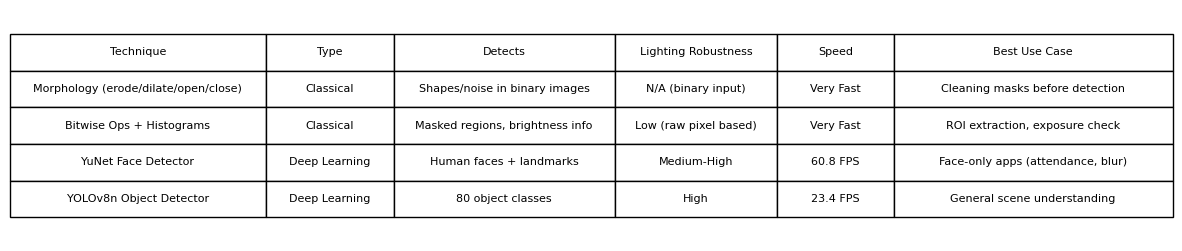

In [65]:
fig, ax = plt.subplots(figsize=(15,3))
ax.axis('off')
col_widths = [0.22, 0.11, 0.19, 0.14, 0.10, 0.24]
tbl = ax.table(cellText=summary_table.values, colLabels=summary_table.columns,
                loc='center', cellLoc='center', colWidths=col_widths)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1,2.2)
plt.savefig('plots/results_table.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 35: Reflection

- For **real-time monitoring** (like a store entrance camera), the best combination is **YuNet alone** if we only care about people's faces, since it is the fastest deep learning option here.
- If the goal is **general scene understanding** (not just faces), **YOLOv8n alone** is better, since one model already covers 80 object types.
- Running **both models together** gives the most information but is the slowest -- good for a one-time analysis, not for a low-power/live camera.
- **Edge deployment** (a small device like a Raspberry Pi or phone) would push us toward the **nano** YOLO model and a **lower resolution** input, trading some accuracy for speed. **Cloud deployment** (a server with a GPU) could afford a bigger YOLO model and run both detectors together at high FPS.


---
## Final Conclusion

**What we did:**
- Used classical image processing (morphology, bitwise operations, histograms) to clean, mask, and understand images at the pixel level
- Loaded a deep learning face detector (YuNet) and tested it on faces with different poses (front-facing, side-profile) and occlusion (sunglasses)
- Loaded a deep learning object detector (YOLOv8n) and tested how confidence and IoU thresholds change its output
- Combined both detectors into one pipeline and measured real speed (FPS) for each part

**Key results from this run:**
- Morphological opening with a 5x5 kernel gave the best noise removal without losing the object shape
- YuNet handled sunglasses fine (both covered faces were still detected with high confidence), but completely missed both faces turned away from the camera -- pose matters more than occlusion for this model
- A very high IoU threshold (0.99) let duplicate boxes survive, showing why Non-Max Suppression matters
- The combined face+object pipeline was slower than either model running alone, as expected

**Final takeaway:** classical image processing (Task 1-2) is best for simple, fast, low-level cleanup, while deep learning detectors (Task 3-4) are best for recognizing real-world objects and faces. Combining both (Task 5) gives the most complete picture, at the cost of speed.
